# Credit card fraud detection: results notebook

This notebook shows every table and figure produced by `src/pipeline.py`. Set `RERUN = True` to repeat the full experiment first (about six minutes).

In [1]:
RERUN = False
import subprocess, sys
if RERUN:
    subprocess.run([sys.executable, '../src/pipeline.py'], check=True)

In [2]:
import json, pandas as pd
from IPython.display import Image, display
T, F = '../results/tables/', '../results/figures/'
json.load(open(T + 'run_meta.json'))

{'seed': 42,
 'rows_raw': 284807,
 'rows_dedup': 283726,
 'train_rows': 198608,
 'test_rows': 85118,
 'train_fraud': 331,
 'test_fraud': 142,
 'leak_test_rows_also_in_train': 456,
 'leak_fraud_rows_also_in_train': 7,
 'best_model': 'Random Forest',
 'runtime_seconds': 370.09434604644775}

## Tuning (3-fold CV on the training split, PR-AUC)

In [3]:
pd.read_csv(T + 'tuning.csv')

,model,best_params,cv_pr_auc,cv_pr_auc_sd
0,Logistic Regression,"{""clf__C"": 1.0}",0.746260,0.025697
1,Decision Tree,"{""clf__max_depth"": 20, ""clf__min_samples_leaf""...",0.737785,0.017124
2,Random Forest,"{""clf__max_depth"": null, ""clf__min_samples_lea...",0.839584,0.006901


## Imbalance strategies on the test set

In [4]:
pd.read_csv(T + 'imbalance_strategies.csv', keep_default_na=False).round(4)

,model,strategy,accuracy,precision,recall,f1,mcc,roc_auc,pr_auc,tn,fp,fn,tp,fit_seconds
0,Logistic Regression,No resampling,0.9991,0.8367,0.5775,0.6833,0.6947,0.9666,0.7043,84960,16,60,82,0.1417
1,Logistic Regression,Class weights,0.9732,0.0527,0.8873,0.0995,0.2126,0.9699,0.6873,82712,2264,16,126,0.2279
2,Logistic Regression,SMOTE,0.9719,0.0500,0.8803,0.0946,0.2059,0.9698,0.6927,82599,2377,17,125,0.4452
3,Decision Tree,No resampling,0.9994,0.8783,0.7113,0.7860,0.7901,0.8799,0.6979,84962,14,41,101,9.2490
4,Decision Tree,Class weights,0.9981,0.4609,0.7465,0.5699,0.5857,0.8730,0.7035,84852,124,36,106,4.8264
5,Decision Tree,SMOTE,0.9960,0.2584,0.7606,0.3857,0.4419,0.8857,0.3824,84666,310,34,108,19.4215
6,Random Forest,No resampling,0.9995,0.9541,0.7324,0.8287,0.8357,0.9371,0.8040,84971,5,38,104,30.5743
7,Random Forest,Class weights,0.9995,0.9619,0.7113,0.8178,0.8269,0.9448,0.8231,84972,4,41,101,12.9923
8,Random Forest,SMOTE,0.9995,0.9237,0.7676,0.8385,0.8418,0.9727,0.8220,84967,9,33,109,50.7867


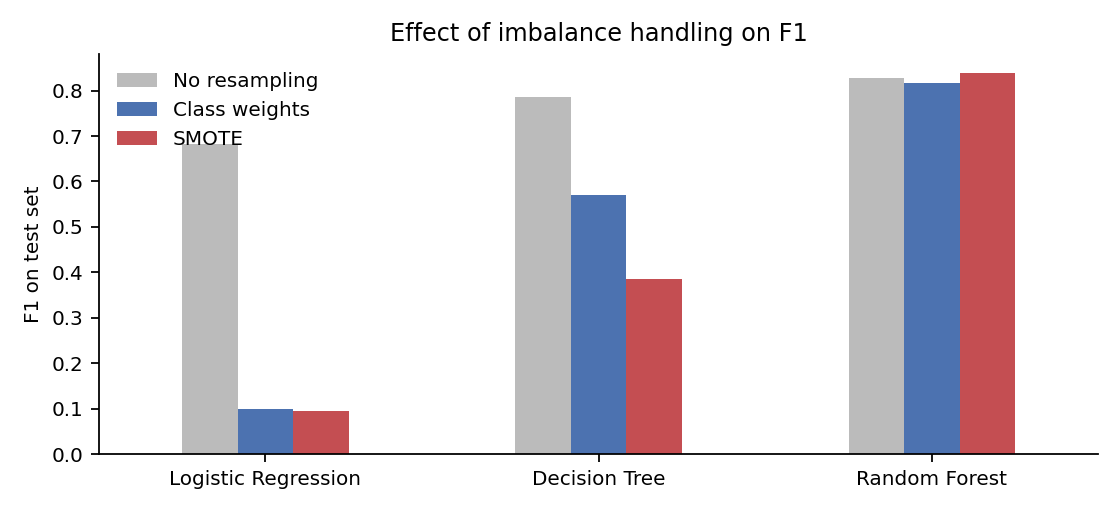

In [5]:
display(Image(F + 'imbalance_f1.png'))

## Main results (class weights, threshold 0.5)

In [6]:
pd.read_csv(T + 'test_results.csv').round(4)

,model,accuracy,precision,recall,f1,mcc,roc_auc,pr_auc,tn,fp,fn,tp,f1_ci_low,f1_ci_high,fit_seconds,latency_ms_per_txn
0,Random Forest,0.9995,0.9619,0.7113,0.8178,0.8269,0.9448,0.8231,84972,4,41,101,0.7663,0.8692,12.9923,0.0005
1,Decision Tree,0.9981,0.4609,0.7465,0.5699,0.5857,0.8730,0.7035,84852,124,36,106,0.5087,0.6263,4.8264,0.0001
2,Logistic Regression,0.9732,0.0527,0.8873,0.0995,0.2126,0.9699,0.6873,82712,2264,16,126,0.0834,0.1174,0.2279,0.0000


In [7]:
pd.read_csv(T + 'mcnemar.csv')

,model_a,model_b,a_right_b_wrong,b_right_a_wrong,chi2,p_value
0,Random Forest,Logistic Regression,2260,25,2184.138293,0.000000e+00
1,Random Forest,Decision Tree,124,9,97.714286,4.833228e-23


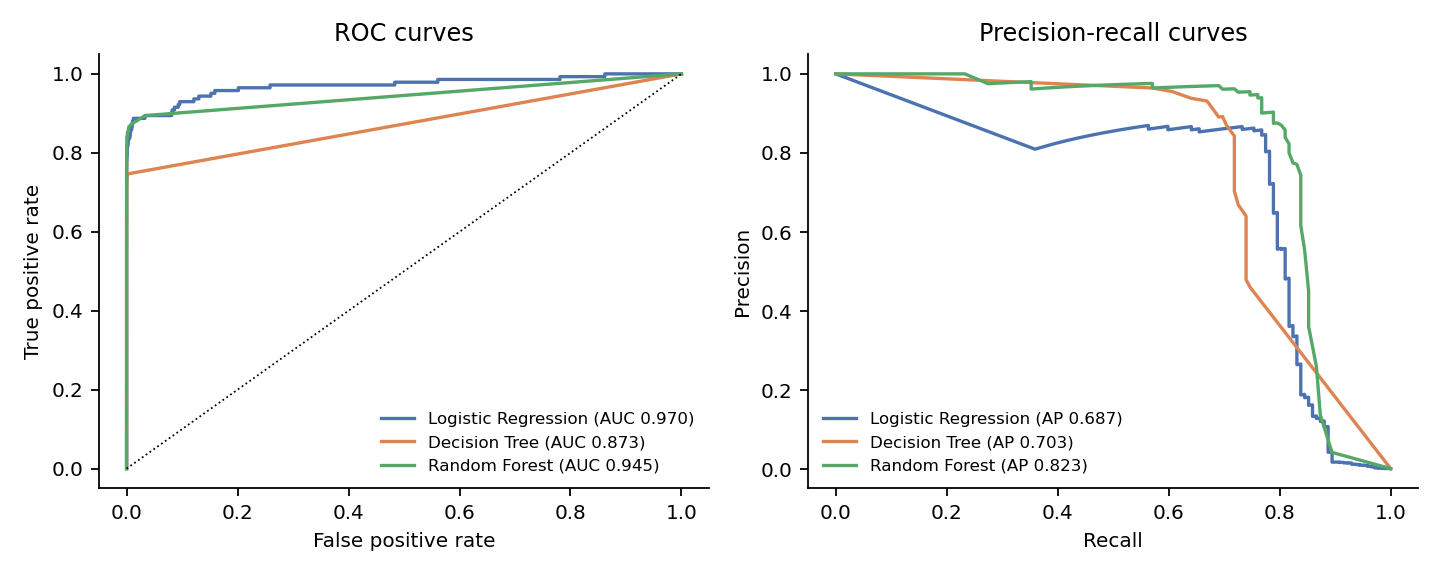

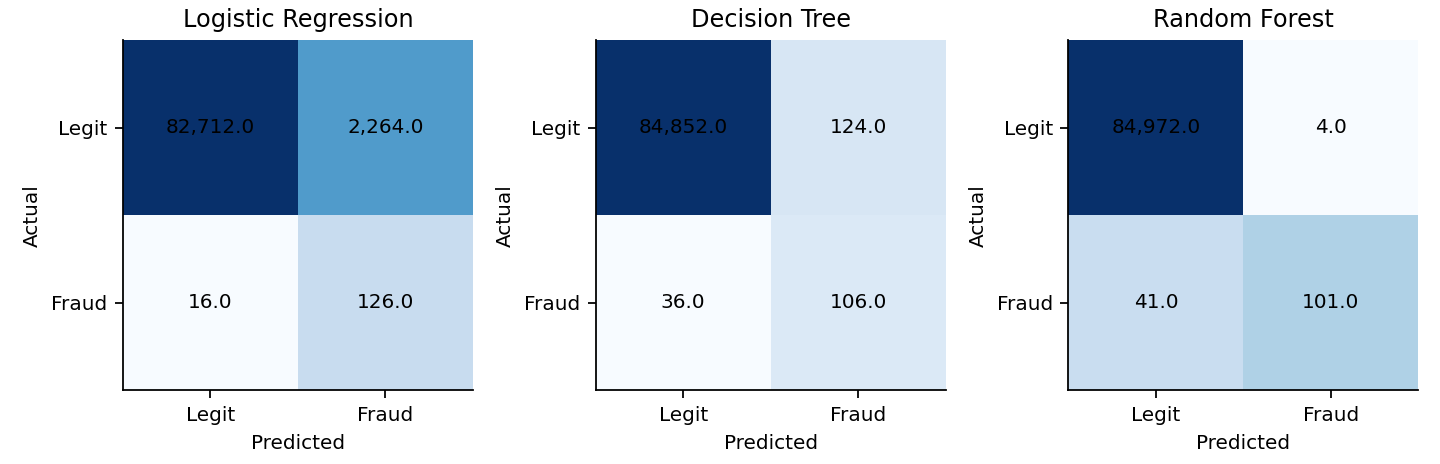

In [8]:
display(Image(F + 'roc_pr_curves.png')); display(Image(F + 'confusion_matrices.png'))

## Threshold chosen on validation data

In [9]:
pd.read_csv(T + 'thresholds.csv').round(4)

,model,threshold,default_precision,default_recall,default_f1,tuned_precision,tuned_recall,tuned_f1,tuned_fp,tuned_fn
0,Logistic Regression,1.0000,0.0527,0.8873,0.0995,0.8644,0.7183,0.7846,16,40
1,Decision Tree,0.9996,0.4609,0.7465,0.5699,0.9556,0.6056,0.7414,4,56
2,Random Forest,0.3400,0.9619,0.7113,0.8178,0.9474,0.7606,0.8438,6,34


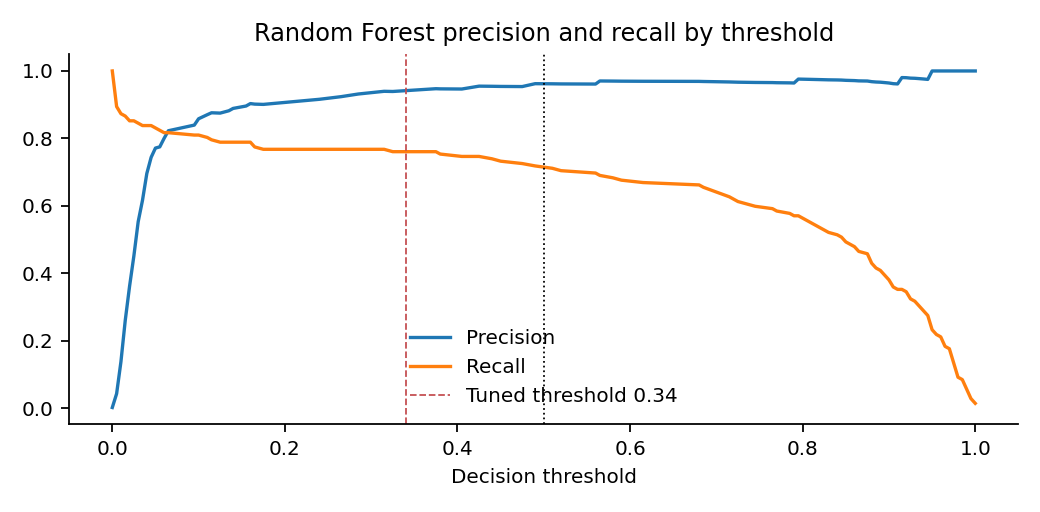

In [10]:
display(Image(F + 'threshold_tradeoff.png'))

## Robustness

In [11]:
pd.read_csv(T + 'temporal_split.csv').round(4)

,model,train_rows,test_rows,accuracy,precision,recall,f1,mcc,roc_auc,pr_auc,tn,fp,fn,tp
0,Logistic Regression,198609,85117,0.9745,0.0426,0.8972,0.0813,0.1923,0.9817,0.7777,82850,2160,11,96
1,Decision Tree,198609,85117,0.9975,0.2923,0.7103,0.4142,0.4547,0.8548,0.6782,84826,184,31,76
2,Random Forest,198609,85117,0.9996,1.0000,0.6542,0.7910,0.8087,0.9450,0.8152,85010,0,37,70


In [12]:
pd.read_csv(T + 'ablation_hour.csv').round(4)

,features,accuracy,precision,recall,f1,mcc,roc_auc,pr_auc,tn,fp,fn,tp
0,With Hour,0.9995,0.9619,0.7113,0.8178,0.8269,0.9448,0.8231,84972,4,41,101
1,Without Hour,0.9995,0.9619,0.7113,0.8178,0.8269,0.9448,0.8235,84972,4,41,101


In [13]:
pd.read_csv(T + 'scalability.csv')

,rows,fit_seconds
0,19860,0.421228
1,49652,1.807538
2,99304,5.598862
3,198608,16.398449


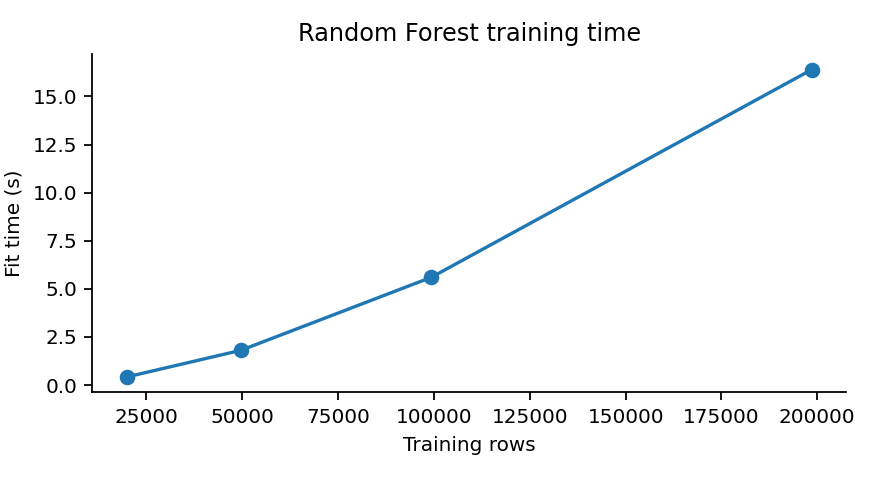

In [14]:
display(Image(F + 'scalability.png'))

## Explainability

In [15]:
pd.read_csv(T + 'feature_importance.csv').head(12).round(4)

,feature,impurity,permutation,lr_coef
0,V4,0.1194,0.0870,0.8898
1,V9,0.0223,0.0365,-0.3649
2,V12,0.1067,0.0349,-1.5051
3,V3,0.0564,0.0317,0.1205
4,V14,0.1974,0.0304,-1.5936
5,V28,0.0050,0.0232,0.7112
6,V18,0.0140,0.0202,-0.2588
7,V2,0.0161,0.0196,0.4930
8,V17,0.0675,0.0189,-1.1635
9,V10,0.1106,0.0164,-1.0701


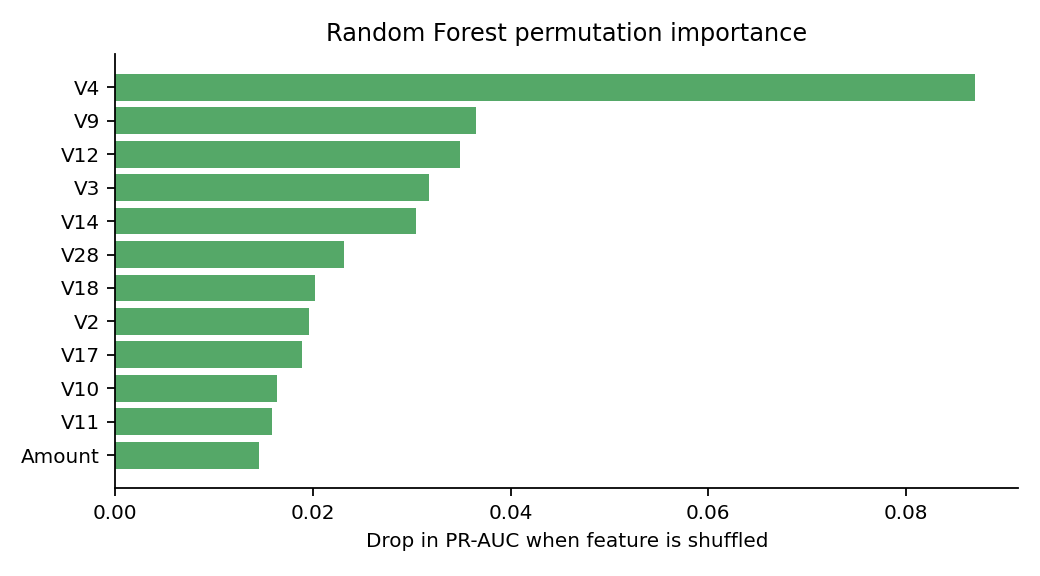

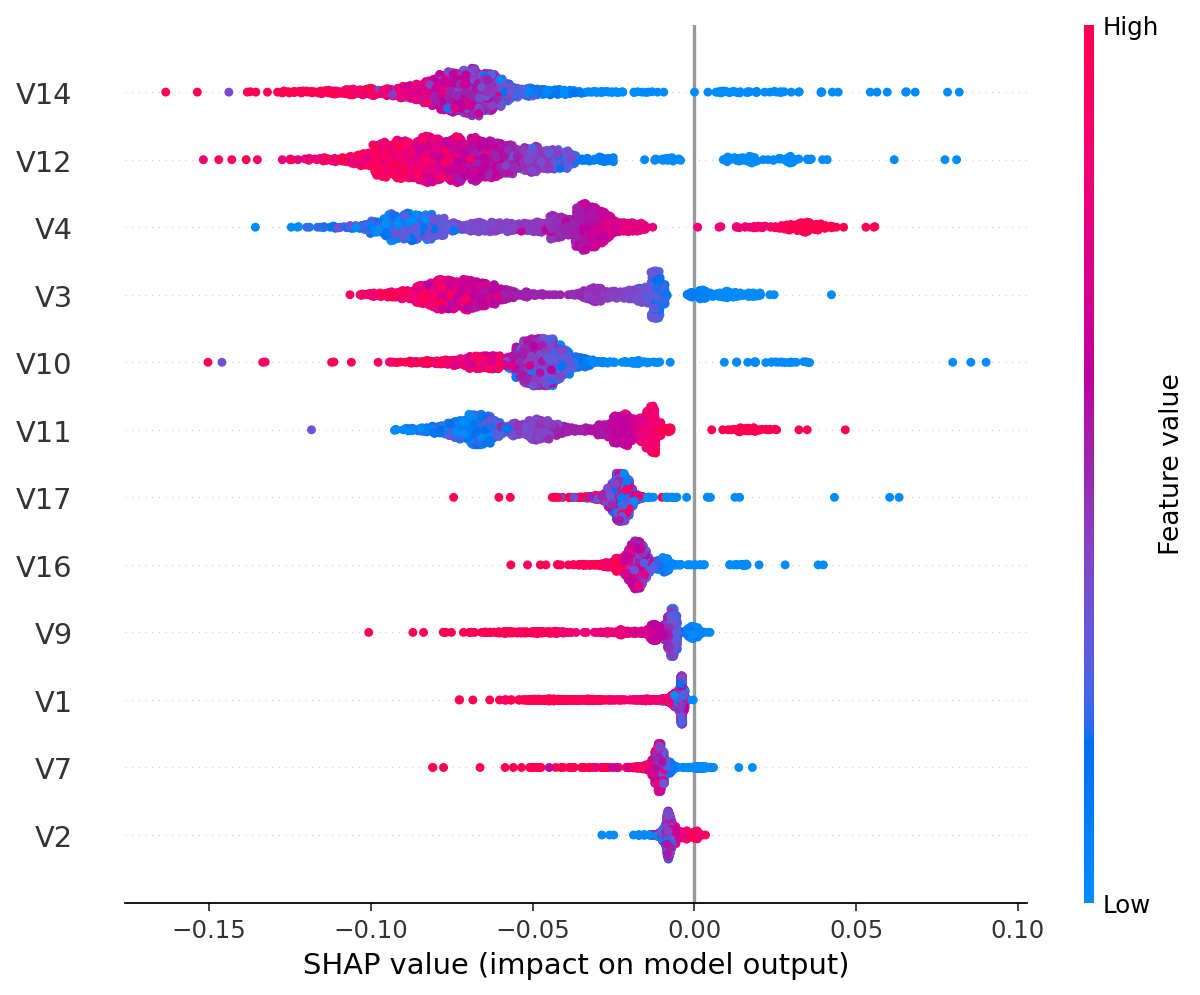

In [16]:
display(Image(F + 'feature_importance.png')); display(Image(F + 'shap_summary.png'))